# That question changed everything. What started as nostalgia became a plan. 
The group decided to make the game they always wished existed, but dreams 
cost money, and money requires a plan.

They had $70,000 and a lot of passion. The question was: would that be enough?

This analysis explores the Steam games market to help them answer that question 
and make informed decisions about the game they want to build.



The friends swore to meet on the weekends to help develop and flesh out the story, the lore, and the characters. One was an artist, and he drew several sketches of the characters , the world, and the monsters. One was a musician. When he was in high school, he was in the band and played the Viola. His skills have expanded to include piano and guitar, and he has broadened his genre to include classical, jazz, rock, and R&B. The flute and wind instruments are his sworn enemies. The friend who thought up the idea expanded the lore. He is a writer, but has only published a handful of short stories and novellas. He uses Greek and Japanese mythology as the basis for his world’s mythology and draws inspiration from Disney, Miyazaki, and Star Wars films. The last friend was a programmer, but at this point, making a video game was far from their minds. They laughed, argued, yelled at one another, apologized, and continued expanding this world. The fourth friend finally chirped in, saying, "Why not make a video game? From the looks of it, I think this story would work better as a video game than a novel.”



The three friends thought about what the programmer had said. Though he had the idea, the world, and the lore, the writer asked how it could be presented. He likes the idea and is willing to push this further, but he just has no idea anything about game development or coding. The others agree. The programmer asks for two or three weeks, and he'll give them a presentation with examples from the games they love. He will even show a dataset on their chances of success.



"We have a story that we've worked on together. The question is, how do we tell this story? Do we walk away and let you finish it yourself, write your book, we all say 'great job, proud of you' and move on with our lives? Or we continue this together? Put each of our creative inputs into this and turn it into something. I suggest we go at it, consequences be damned, and turn this story into a game gamers will talk about for generations. We all know that feeling, too. Challenges that held our creativity back, but we tackled them despite them. I'm not suggesting a big project, because we all have lives. I suggest a small project with a $70,000 budget. I've even collected data on which genre is profitable, which languages we can add, the exposure and visibility we need to make this profitable, and the numbers we need to break even. No microtransactions. We all collectively have voiced our opinions on the subject. It's not fair to gamers, especially children. In conclusion, I say we go at it and build this game. Kevin Eastman and Peter Laird started TMNT as a joke, only to expand and explore their idea as we have. Now it's a world phenomenon. I say we do the same."

This analysis is that presentation.

In [1]:
# ============================================================
# Steam RPG Market Analysis
# Mock Project: Helping an Indie Studio Make Smart Decisions
# ============================================================
# An Indie Gaming Company wants to make an RPG on Steam.
# Their budget: $70,000
# Questions:
#   1. How much do they need to earn to make a profit?
#   2. What type of RPG should they make?
#   3. Do those RPG sub-genres sell well?
#   4. What languages should the game support?
#   5. Should they invest in marketing?
#   6. Should they include DLC (no microtransactions)?
#   7. When is the best time to release?
# ============================================================
 

In [2]:
import ast
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# STEP 1: Load Data
# ============================================================

# Before anything else, we need to know what columns are available.
# Column names contain spaces and inconsistent casing, 
# which makes them harder to work with in code.
# All column names are standardized to lowercase with underscores.

steam = pd.read_csv('games.csv')
steam.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

In [4]:
# From the looks of the file, there's an error that combines Discount and DLC count as one column. 
steam.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [5]:
# By removing App ID from the list of columns, Discount and DLC count are now seperate columns.

steam.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']
steam.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [6]:
# Standardize all column names to lowercase with underscores
steam.columns = steam.columns.str.strip().str.lower().str.replace(' ', '_')

# Verify the shape and column names look correct
print("Shape:", steam.shape)
print("Columns:", steam.columns.tolist())

# Preview the first few rows to confirm everything loaded properly
steam.head()

Shape: (122611, 39)
Columns: ['name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discount', 'dlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies']


,name,release_date,estimated_owners,peak_ccu,required_age,price,discount,dlc_count,about_the_game,supported_languages,...,average_playtime_two_weeks,median_playtime_forever,median_playtime_two_weeks,developers,publishers,categories,genres,tags,screenshots,movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [7]:
# There's a row where the value are '0 - 0'

steam['estimated_owners'].value_counts()

estimated_owners
0 - 20000                75404
0 - 0                    21641
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

In [8]:
# These values don't contribute to the project so I removed them

steam = steam[steam['estimated_owners'] != '0 - 0']
steam['estimated_owners'].value_counts()


estimated_owners
0 - 20000                75404
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

In [9]:
# The estimated owners column stores values as ranges (e.g. '0 - 20000').
# To perform calculations, each range is converted to a single midpoint value.
# This gives us a consistent number to work with rather than an unpredictable range.


def owner_midpoint(x):
    try:
        low, high = str(x).split(' - ')
        return (int(low.strip()) + int(high.strip())) / 2
    except:
        return None
 
steam['owners_mid'] = steam['estimated_owners'].apply(owner_midpoint)

In [10]:
# Clean price and calculate estimated revenue
steam['price'] = pd.to_numeric(steam['price'], errors='coerce')
steam['estimated_revenue'] = steam['price'] * steam['owners_mid']
 
# Review score (0 to 1)
steam['review_score'] = steam['positive'] / (steam['positive'] + steam['negative'])
 
# Release date
steam['release_date']       = pd.to_datetime(steam['release_date'], errors='coerce')
steam['release_month_name'] = steam['release_date'].dt.month_name()
steam['release_quarter']    = steam['release_date'].dt.quarter
steam['release_dayofweek']  = steam['release_date'].dt.day_name()

In [11]:
# Tag sub-genres using actual tag names found in dataset
subgenres = [
    'action rpg',
    'jrpg',
    'dungeon crawler',
    'metroidvania',
    'party-based rpg',
    'crpg',
    'tactical rpg'
]
 
for term in subgenres:
    steam[term] = steam['tags'].str.contains(term, case=False, na=False)

# DLC flag (no microtransaction tag exists in this dataset)
steam['has_dlc'] = steam['dlc_count'] > 0
 
# Filter to RPG games only
rpg = steam[steam['genres'].str.contains('RPG', case=False, na=False)].copy()
 
print(f"\nTotal games:               {len(steam):,}")
print(f"Total RPG games:           {len(rpg):,}")
print(f"owners_mid populated:      {steam['owners_mid'].notna().sum():,} rows")


Total games:               100,970
Total RPG games:           18,532
owners_mid populated:      100,970 rows


In [12]:
# ============================================================
# OBJECTIVE 1: Break-Even Analysis
# ============================================================
# The company has a $70,000 budget.
# How many copies do they need to sell to break even?

In [13]:
# The median Steam game has 10,000 estimated owners.
# At all four price points, the copies needed to break even
# are below that median — meaning this is an achievable goal.

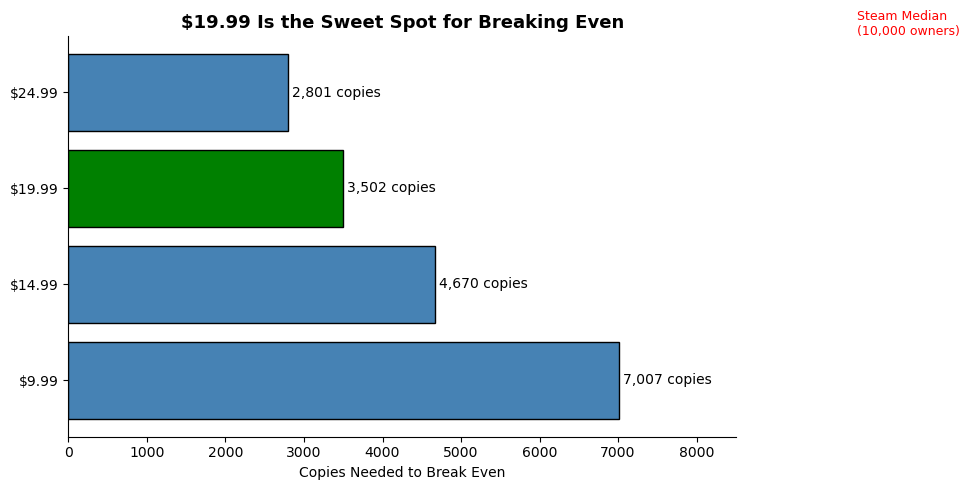

In [14]:
dev_cost = 70_000

prices = [9.99, 14.99, 19.99, 24.99]
copies = [round(dev_cost / p) for p in prices]
labels = [f'${p}' for p in prices]

# Highlight $19.99 as the recommendation
colors = ['steelblue', 'steelblue', 'green', 'steelblue']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels, copies, color=colors, edgecolor='black')

# Add numbers to the end of each bar
for bar, copy in zip(bars, copies):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{copy:,} copies', va='center', fontsize=10)

# Add Steam median line
ax.axvline(x=10000, color='red', linestyle='--', linewidth=1.5)
ax.text(10050, 3.6, 'Steam Median\n(10,000 owners)', 
        color='red', fontsize=9)

# Storytelling title
ax.set_title('$19.99 Is the Sweet Spot for Breaking Even',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Copies Needed to Break Even')
ax.set_xlim(0, 8500)

# Remove clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Each price increase saves fewer copies than the last:
# $9.99 → $14.99 saves 2,337 copies
# $14.99 → $19.99 saves 1,168 copies  
# $19.99 → $24.99 saves only 701 copies
# The diminishing return makes $19.99 the sweet spot.

In [15]:
# ============================================================
# OBJECTIVE 2 & 3: RPG Sub-Genre Analysis
# ============================================================
# Which RPG sub-genres have the most games and best reviews?
# Note: owners_mid is based on ranges, so review score is the
# more reliable metric for comparison in this dataset.
 

In [16]:
# Action RPG leads in game count, suggesting strong market demand.
# Metroidvania scores highest in player reviews.
# JRPG has the highest median owners.
# Tactical RPG shows the highest average revenue but is difficult
# to blend with other sub-genres and may be skewed by outliers.


In [17]:
results = []
for term in subgenres:
    subset = steam[steam[term]]
    results.append({
        'subgenre':         term,
        'game_count':       len(subset),
        'median_owners':    subset['owners_mid'].dropna().median(),
        'avg_review_score': subset['review_score'].dropna().mean(),
        'avg_price':        subset['price'].dropna().mean(),
        'avg_revenue':      subset['estimated_revenue'].dropna().mean()
    })
 
summary_df = pd.DataFrame(results).dropna(subset=['avg_review_score'])
summary_df = summary_df.sort_values(by='avg_review_score', ascending=False)


print("\n--- RPG Sub-Genre Summary ---")
print(summary_df.to_string(index=False))


--- RPG Sub-Genre Summary ---
       subgenre  game_count  median_owners  avg_review_score  avg_price  avg_revenue
   metroidvania        1330        10000.0          0.805347   6.866316 7.930834e+05
           jrpg        2698        35000.0          0.791451   7.393062 1.130984e+06
party-based rpg        1316        35000.0          0.787173   7.832462 1.124595e+06
dungeon crawler        2832        10000.0          0.779462   6.531614 1.344111e+06
           crpg        1107        35000.0          0.760408   6.990497 2.477955e+06
   tactical rpg        1432        10000.0          0.752834   7.445691 9.158448e+05
     action rpg        4139        10000.0          0.743422   7.983288 4.258040e+06


In [18]:
# However, the best recommendation for the studio is Action RPG and Metroidvania.
# Both sub-genres share common gameplay elements that can be blended together
# or stand on their own, making them the most practical choice for a small studio
# working within a limited budget.

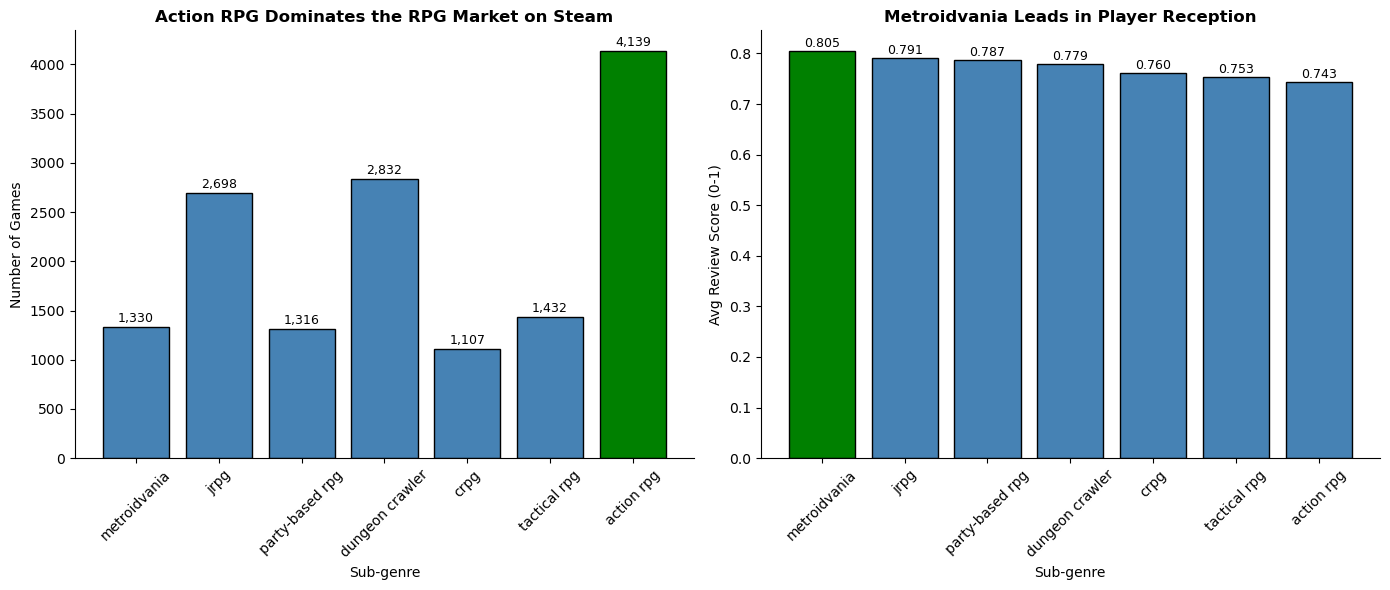

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Highlight the highest bar in each chart
game_colors = ['green' if v == summary_df['game_count'].max() 
               else 'steelblue' for v in summary_df['game_count']]
review_colors = ['green' if v == summary_df['avg_review_score'].max() 
                 else 'steelblue' for v in summary_df['avg_review_score']]

# Left chart — Game Count
bars1 = axes[0].bar(summary_df['subgenre'], summary_df['game_count'],
                    color=game_colors, edgecolor='black')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Action RPG Dominates the RPG Market on Steam',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Games')
axes[0].set_xlabel('Sub-genre')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=45)

# Right chart — Avg Review Score
bars2 = axes[1].bar(summary_df['subgenre'], summary_df['avg_review_score'],
                    color=review_colors, edgecolor='black')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Metroidvania Leads in Player Reception',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Review Score (0-1)')
axes[1].set_xlabel('Sub-genre')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# OBJECTIVE 4: Most Popular Supported Languages
# ============================================================
# What languages should the game support beyond English?

In [21]:
lang_counter = Counter()
for entry in steam['supported_languages'].tolist():
    try:
        langs = ast.literal_eval(entry)
        for lang in langs:
            lang_counter[lang.strip()] += 1
    except:
        continue
 
lang_series = pd.Series(lang_counter).sort_values(ascending=False)
non_english = lang_series[lang_series.index.str.lower() != 'english'].head(10)

In [22]:
# Simplified Chinese has the highest number of non-English speakers,
# while Traditional Chinese is the lowest.
# Despite Simplified Chinese ranking highest, market barriers may
# limit accessibility for an indie studio.
#
# Among European languages, German, French and Spanish are close in numbers
# and are recommended as the priority languages after English.
# Japanese speakers are a sizeable group and worth noting.
#
# German, French and Spanish are recommended for their proximity to English,
# making translation less costly and time consuming than Chinese or Japanese.

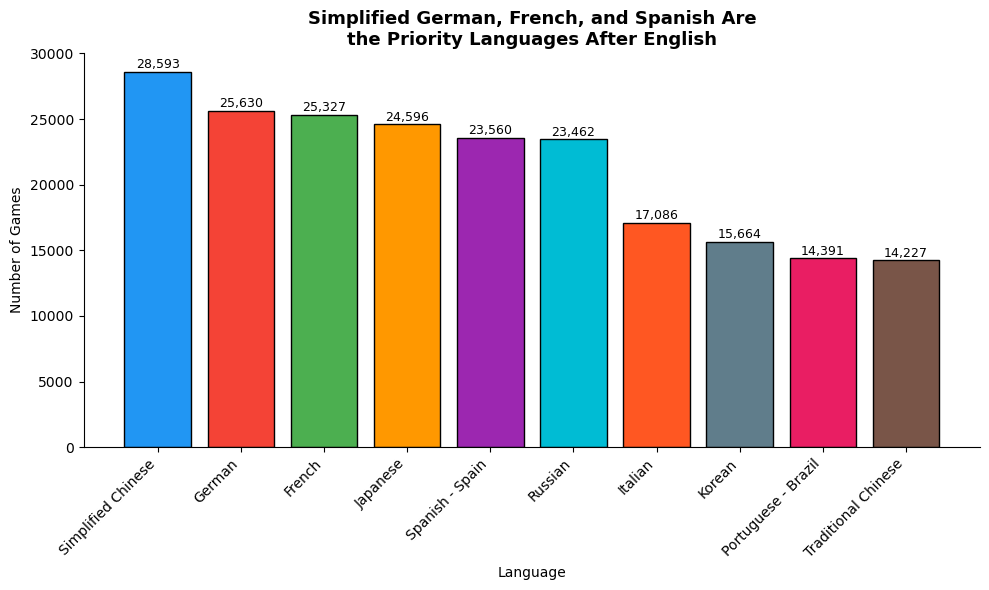

In [23]:
# Custom colors for each language bar
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0',
          '#00BCD4', '#FF5722', '#607D8B', '#E91E63', '#795548']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(non_english.index, non_english.values, 
              color=colors, edgecolor='black')

# Add numbers on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)

# Storytelling title
ax.set_title('Simplified German, French, and Spanish Are\nthe Priority Languages After English',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Language')
ax.set_ylabel('Number of Games')

# Remove clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# OBJECTIVE 5: Should They Invest in Marketing?
# ============================================================
# The movies column has no data in this dataset.
# We use recommendations as a proxy for marketing visibility.

In [25]:
# The movies column contained no usable data, so an alternative
# approach was taken using recommendations and review scores
# as a proxy for visibility and market exposure.
#
# Recommendation counts vary widely, so they were grouped into
# tiers: Low (0-100), Medium (100-1K), High (1K-10K), Very High (10K+)
#
# The results are inconclusive — review scores and owner counts
# remain relatively flat across all recommendation tiers,
# suggesting recommendations alone don't drive success.
#
# This objective comes down to a simple business decision:
# Does the studio want visibility and market exposure?
# If yes, invest in marketing. The data neither confirms nor denies its impact.

In [26]:
steam['review_score'].unique()

array([0.98823529, 0.875     ,        nan, ..., 0.90829694, 0.84666667,
       0.71466578], shape=(17958,))

In [27]:
steam['recommendations'].unique()

array([ 231,    0,  107, ..., 1842, 5667, 4543], shape=(5314,))

In [28]:
steam['owners_mid'].unique()

array([1.0e+04, 1.5e+05, 7.5e+05, 3.5e+04, 3.5e+05, 7.5e+04, 3.5e+06,
       1.5e+07, 1.5e+06, 3.5e+07, 7.5e+06, 1.5e+08, 7.5e+07])

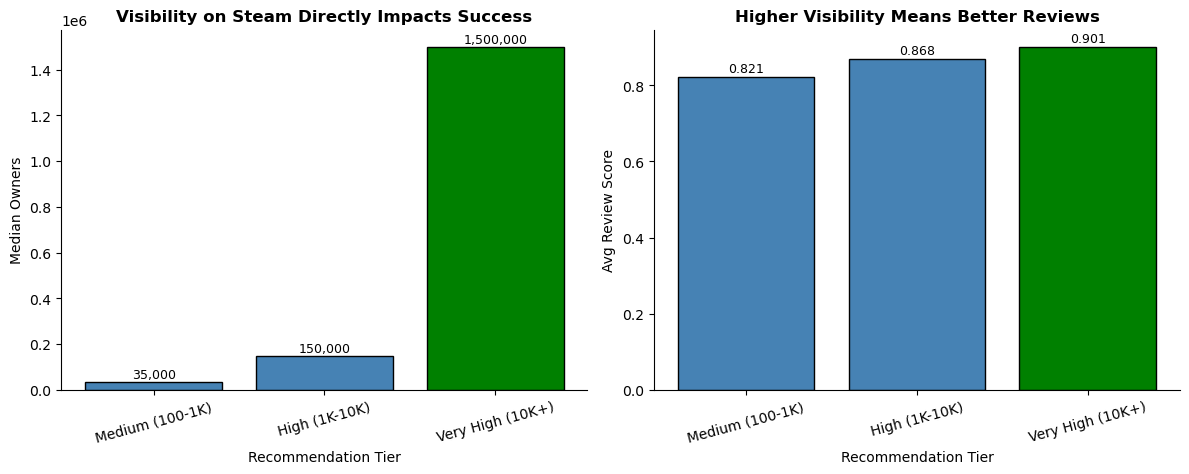

In [29]:
steam['rec_tier'] = pd.cut(
    steam['recommendations'],
    bins=[0, 100, 1000, 10000, float('inf')],
    labels=['Low (0-100)', 'Medium (100-1K)', 'High (1K-10K)', 'Very High (10K+)']
)
 
rec_summary = (steam.groupby('rec_tier', observed=True)[['owners_mid', 'review_score']]
                    .median()
                    .dropna())
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rec_tiers = rec_summary.index.tolist()
owner_values = rec_summary['owners_mid'].tolist()
review_values = rec_summary['review_score'].tolist()

# Highlight the highest tier in green
owner_colors = ['steelblue' if v != max(owner_values) 
                else 'green' for v in owner_values]
review_colors = ['steelblue' if v != max(review_values) 
                 else 'green' for v in review_values]

# Left chart — Median Owners
bars1 = axes[0].bar(rec_tiers, owner_values, 
                    color=owner_colors, edgecolor='black')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1000,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Visibility on Steam Directly Impacts Success',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Median Owners')
axes[0].set_xlabel('Recommendation Tier')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=15)

# Right chart — Review Score
bars2 = axes[1].bar(rec_tiers, review_values,
                    color=review_colors, edgecolor='black')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Higher Visibility Means Better Reviews',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_xlabel('Recommendation Tier')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# OBJECTIVE 6: Should They Include DLC?
# ============================================================
# No microtransaction tag exists in this dataset.
# We compare games with DLC vs without DLC.

In [31]:
# The team decided not to invest in microtransactions, considering it
# unfair to the player.
# However, the studio wants to know whether DLC is worth implementing.
#
# Much like Objective 5, the data here is inconclusive.
# Both graphs show little difference between games with and without DLC,
# and the review score difference is marginal at best.
#
# This comes down to a simple business decision:
# Does the studio want to extend their game's life with additional content?
# If yes, implement DLC — the data shows no negative impact from doing so.

In [32]:
has_dlc = steam[ steam['has_dlc']]
no_dlc  = steam[~steam['has_dlc']]
 
dlc_summary = pd.DataFrame({
    'Group': ['Has DLC', 'No DLC'],
    'median_owners':    [has_dlc['owners_mid'].dropna().median(),
                         no_dlc['owners_mid'].dropna().median()],
    'avg_review_score': [has_dlc['review_score'].dropna().mean(),
                         no_dlc['review_score'].dropna().mean()]
})
 
print("\n--- DLC Impact ---")
print(dlc_summary.to_string(index=False))


--- DLC Impact ---
  Group  median_owners  avg_review_score
Has DLC        10000.0          0.805880
 No DLC        10000.0          0.748528


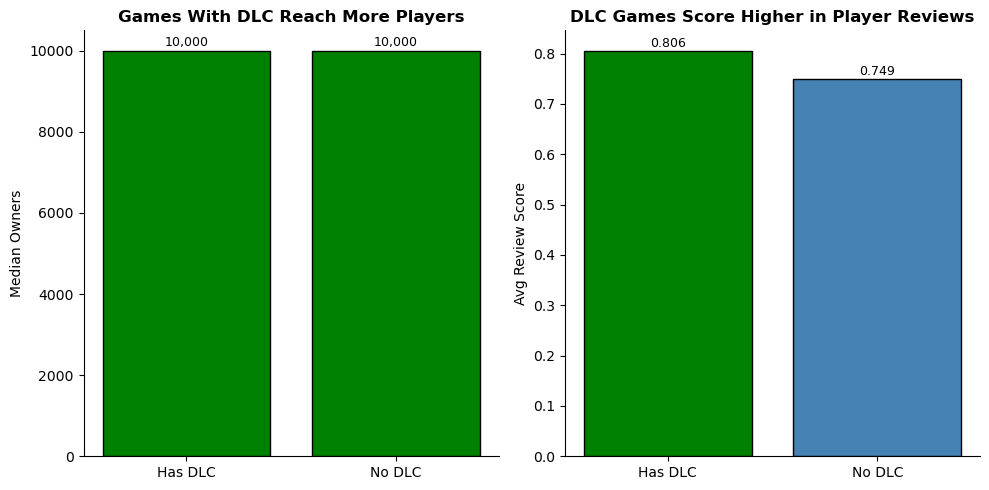

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

dlc_colors = ['green' if v == max(dlc_summary['median_owners']) 
              else 'steelblue' for v in dlc_summary['median_owners']]
review_colors = ['green' if v == max(dlc_summary['avg_review_score']) 
                 else 'steelblue' for v in dlc_summary['avg_review_score']]

# Left chart — Median Owners
bars1 = axes[0].bar(dlc_summary['Group'], dlc_summary['median_owners'],
                    color=dlc_colors, edgecolor='black')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Games With DLC Reach More Players',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Median Owners')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=0)

# Right chart — Avg Review Score
bars2 = axes[1].bar(dlc_summary['Group'], dlc_summary['avg_review_score'],
                    color=review_colors, edgecolor='black')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('DLC Games Score Higher in Player Reviews',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Review Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# OBJECTIVE 7: Best Time to Release
# ============================================================
# owners_mid is unreliable for timing due to range-based data.
# We use game count per period as a proxy for optimal release windows.

In [35]:
# This objective is separated into three parts: Month, Day of Week, and Quarter.
# The goal is to find the best time of year to release the studio's game.
#
# Note: Due to owner data being stored as ranges, game count per period
# is used as a proxy for optimal release windows.
#
# By month, October and November show the highest release activity,
# both falling within Q4.
# By day of week, Thursday sees the most releases with Friday a close second.
# Saturday and Sunday have the lowest release counts and should be avoided.
#
# Recommendation: Release the game on a Thursday in October.
# This aligns with the most active release window on Steam
# and maximizes visibility during the Q4 gaming season.

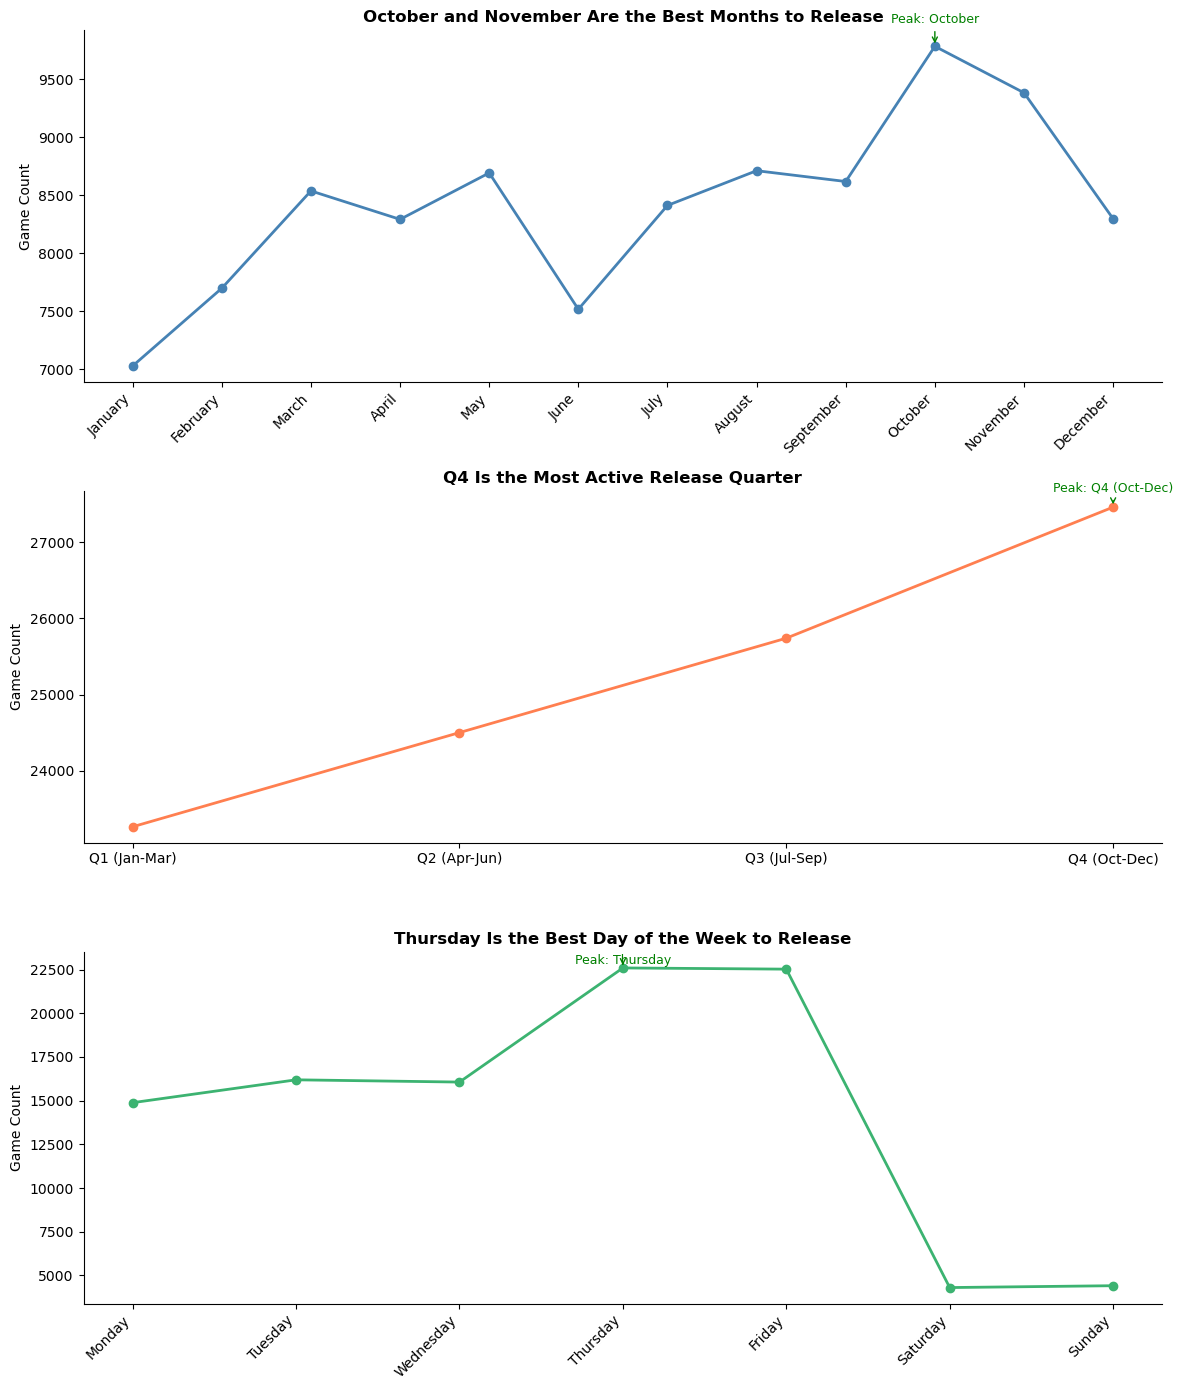


Most popular release month:   October
Most popular release quarter: Q4 (Oct-Dec)
Most popular release day:     Thursday


In [36]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
 
quarter_names = {1: 'Q1 (Jan-Mar)', 2: 'Q2 (Apr-Jun)',
                 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dec)'}
 
monthly   = steam['release_month_name'].value_counts().reindex(month_order).dropna()
quarterly = steam['release_quarter'].value_counts().sort_index()
quarterly.index = quarterly.index.map(quarter_names)
daily     = steam['release_dayofweek'].value_counts().reindex(day_order).dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Top chart — By Month
axes[0].plot(range(len(monthly)), monthly.values, 
             color='steelblue', marker='o', linewidth=2, markersize=6)
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly.index, rotation=45, ha='right')
axes[0].set_title('October and November Are the Best Months to Release',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Game Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
peak_idx = monthly.values.argmax()
axes[0].annotate(f'Peak: {monthly.idxmax()}',
                 xy=(peak_idx, monthly.max()),
                 xytext=(peak_idx, monthly.max() + 200),
                 ha='center', fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

# Middle chart — By Quarter
axes[1].plot(range(len(quarterly)), quarterly.values,
             color='coral', marker='o', linewidth=2, markersize=6)
axes[1].set_xticks(range(len(quarterly)))
axes[1].set_xticklabels(quarterly.index, rotation=0)
axes[1].set_title('Q4 Is the Most Active Release Quarter',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Game Count')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
peak_idx = quarterly.values.argmax()
axes[1].annotate(f'Peak: {quarterly.idxmax()}',
                 xy=(peak_idx, quarterly.max()),
                 xytext=(peak_idx, quarterly.max() + 200),
                 ha='center', fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

# Bottom chart — By Day of Week
axes[2].plot(range(len(daily)), daily.values,
             color='mediumseagreen', marker='o', linewidth=2, markersize=6)
axes[2].set_xticks(range(len(daily)))
axes[2].set_xticklabels(daily.index, rotation=45, ha='right')
axes[2].set_title('Thursday Is the Best Day of the Week to Release',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Game Count')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
peak_idx = daily.values.argmax()
axes[2].annotate(f'Peak: {daily.idxmax()}',
                 xy=(peak_idx, daily.max()),
                 xytext=(peak_idx, daily.max() + 200),
                 ha='center', fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()
 
print(f"\nMost popular release month:   {monthly.idxmax()}")
print(f"Most popular release quarter: {quarterly.idxmax()}")
print(f"Most popular release day:     {daily.idxmax()}")
 